In [57]:
import feedparser
import requests
import urllib.parse
from dotenv import load_dotenv
import os
from langchain_mistralai import ChatMistralAI
from langchain_core.prompts import PromptTemplate
from firecrawl import Firecrawl
import time
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, HttpUrl, Field
from typing import List
from langchain_core.runnables import RunnableLambda, RunnableParallel
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [58]:
load_dotenv()

True

In [59]:
rss_category_feeds ={
    "Sports":{
        "Football":[
                "https://feeds.bbci.co.uk/sport/football/rss.xml","https://www.espn.com/espn/rss/soccer/news",
                "https://www.goal.com/feeds/en/news","https://www.skysports.com/rss/12040"
        ],
        "Cricket":[
            "https://www.espncricinfo.com/rss/content/story/feeds/0.xml","https://feeds.bbci.co.uk/sport/cricket/rss.xml","https://www.cricbuzz.com/cricket-rss-feeds",
            "https://livemint.com/rss/sports"
        ],
        "BasketBall":[
            "https://www.nba.com/news/rss.xml","https://www.espn.com/espn/rss/nba/news",
            "https://www.cbssports.com/rss/headlines/nba"
        ],
        "Hockey":[
            "https://www.espn.com/espn/rss/nhl/news","https://www.cbssports.com/rss/headlines/nhl","https://www.nbcsports.com/nhl",
            "https://www.nhl.com/rss/news.xml"
        ]
    },
    "Tech":{
        "AI":[
            "https://www.technologyreview.com/feed/","https://venturebeat.com/category/ai/feed/",
            "https://www.techrepublic.com/rssfeeds/articles","https://spectrum.ieee.org/feeds/feed.rss"
        ],
        "Startups & Business":[
            "https://techcrunch.com/category/startups/feed/","https://venturebeat.com/feed/","https://www.geekwire.com/feed/",
            "https://www.producthunt.com/feed"
        ],
        "Mobile & Apps" :[
            "https://www.androidauthority.com/feed/","https://9to5google.com/feed/","https://9to5mac.com/feed/"
        ],
        "Cybersecurity":[
            "https://krebsonsecurity.com/feed/","https://feeds.feedburner.com/TheHackersNews","https://www.darkreading.com/rss.xml"
        ],
        "General Tech News":[
            "https://techcrunch.com/feed/","https://www.theverge.com/rss/index.xml",
            "https://www.digitaltrends.com/feed/","https://www.cnet.com/rss/all/"
        ]
    },
    "Finance":{
        "General Finance & Markets":[
            "https://feeds.bloomberg.com/markets/news.rss","https://feeds.reuters.com/reuters/businessNews",
            "https://feeds.a.dj.com/rss/RSSMarketsMain.xml","https://www.economist.com/finance-and-economics/rss.xml"
        ],
        "Stocks & Investing":[
            "https://www.nasdaq.com/feed/nasdaq-originals/rss.xml","https://finance.yahoo.com/news/rssinde",
            "https://www.investing.com/rss/news.rss","https://www.morningstar.com/feeds/all-articles"
        ],
        "Crypto & Blockchain":[
            "https://www.coindesk.com/arc/outboundfeeds/rss/","https://bitcoinmagazine.com/feed",
            "https://cointelegraph.com/rss","https://decrypt.co/feed"
        ],
        "Central Banks & Policy":[
            "https://www.ecb.europa.eu/rss/press.html","https://www.federalreserve.gov/feeds/press_all.xml",
            "https://www.imf.org/en/News/rss?language=eng"
        ]
    },
    "Science":{
        "General Science News":{
            "https://www.sciencedaily.com/rss/all.xml","https://www.newscientist.com/feed/home/",
            "https://www.livescience.com/feeds.xml","https://www.sciencenews.org/feed"
        },
        "Biology & Medicine":[
            "https://pubmed.ncbi.nlm.nih.gov/rss/search/","https://www.nih.gov/news-events/news-releases/feed.xml",
            "https://www.science.org/action/showFeed?type=axatoc&feed=rss&jc=science"
        ],
        "Space & Astronomy":[
            "https://www.nasa.gov/rss/dyn/breaking_news.rss","https://www.space.com/feeds/all",
            "https://skyandtelescope.org/feed/","https://www.astronomy.com/feed"
        ],
        "Physics & Chemistry":[
            "https://pubs.aip.org/rss/site_1000023/1000024.xml","https://spectrum.ieee.org/feeds/feed.rss",
            "https://cen.acs.org/rss/latest.xml","https://physicsworld.com/feed/"
        ],
        " Environment & Climate":[
            "https://www.nationalgeographic.com/rss","https://www.climate.gov/feeds/all.rss",
            "https://www.eurekalert.org/rss/all.xml","https://www.nsf.gov/rss/rss_www_news.xml"
        ]
    }

}

In [60]:
app = Firecrawl(api_key=os.environ.get("FIRECRAWL_API_KEY",""))
model=ChatMistralAI()

In [61]:
class NewsItem(BaseModel):
    """Represents a single filtered news item returned by the agent."""
    title: str = Field(..., description="The attention-grabbing news headline")
    source: str = Field(..., description="The news source (e.g. bbci, espn, skysports)")
    url: str = Field(..., description="The full URL to the article")


class FilteredNewsResponse(BaseModel):
    """Top 4 filtered news items selected by the agent."""
    items: List[NewsItem] = Field(...,min_length=4,max_length=4,description="Exactly 4 most interesting news items"
    )

class SummaryStructure(BaseModel):
    """ This  is used for summary generation. """
    summary: str = Field(...,description="3-4 line summary of the given markdown text")

In [62]:
class SportState(TypedDict):
    category: str 
    sport: str 
    url:list
    config: dict
    filtered_cnt: FilteredNewsResponse

    summary : dict

In [63]:
def extract_sport_url(state:SportState):
    category=state['category']
    sport=state['sport']
    return {"url":rss_category_feeds[category][sport]}

In [64]:
def feedparsing(url: str) -> list:
    source = url.split(".")[1]
    result = feedparser.parse(url)
    top4_results = result["entries"][0:4]

    top4_data = []
    for res in top4_results:
        title = res["title"]
        href_url = res["links"][0]["href"]
        top4_data.append({
            "title": title,
            "link": href_url
        })

    return [{"source": source, "information": top4_data}]

In [65]:
def create_runnable_football(state:SportState):
    urls=state['url']
    src_url = []
    for url in urls:
        source = url.split(".")[1]
        src_url.append({"source": source, "url": url})

    parallel_map = {
        item["source"]: RunnableLambda(lambda x, u=item["url"]: feedparsing(u))
        for item in src_url
    }

    parallel_chain = RunnableParallel(parallel_map) 

    return {"config":parallel_chain.invoke({})}

In [66]:
def filter_content(state:SportState) :
    config=state['config']
    
    FILTER_PROMPT = """
    You are a sports news curator. Your job is to select the TOP 4 most attention-grabbing and engaging news titles from the list below.

    ## Selection Criteria (in order of priority):
    1. **Controversy or Drama** - Fines, bans, transfers, conflicts
    2. **Big Club / Star Player involvement** - Real Madrid, Chelsea, Liverpool, Man Utd,Barcelona etc.
    3. **Urgency or Breaking News** - Decisions, warnings, surprises
    4. **Emotional Hook** - Quotes, player reactions, fan-facing stories

    ## Input News List:
   {news_data}

   ## Instructions:
   - Analyze ALL titles across ALL sources
   - Pick exactly TOP 4 that will grab the most user attention
   - Avoid duplicates (same story from different sources = pick only one)
   - No explanation, no markdown.
    {format_instructions}
    """

    parser=PydanticOutputParser(pydantic_object=FilteredNewsResponse)

    final_template=PromptTemplate(
       template=FILTER_PROMPT,
       input_variables=["news_data"],
       partial_variables={"format_instructions":parser.get_format_instructions()}
    )

    chain = final_template | model | parser 

    result=chain.invoke({"news_data":config})
    return {"filtered_cnt":result}

In [67]:
def scrape_and_summarize(url,source,chain):
    res=app.scrape(url)
    summ= chain.invoke({"text":res.markdown})
    return {
        "source":source,
        "summary":summ.summary
    }

In [68]:
def generate_summary(state:SportState):
    filtered_cnt=state['filtered_cnt']
    summ_parser = PydanticOutputParser(pydantic_object=SummaryStructure)

    summ_prompt = PromptTemplate(
        template="""You are a precise summarization assistant.

        Your task:
        - Read the markdown text carefully
        - Ignore all formatting, symbols, and redundant content
        - Extract only the core, meaningful information
        - Write a clear and concise summary in exactly 2-3 sentences
        - Do NOT include opinions, filler phrases, or repetition
        - No explanation, no markdown.

        Text:
        {text} \n
        {format_instructions}
        """,
        input_variables=["text"],
        partial_variables={"format_instructions": summ_parser.get_format_instructions()}
    )

    chain = summ_prompt | model | summ_parser

    parallel_map = {
        item.title: RunnableLambda(
            lambda x, u=item.url, s=item.source: scrape_and_summarize(u, s,chain)
        )
        for item in filtered_cnt.items
    }

    parallel_chain = RunnableParallel(parallel_map)

    return {'summary':parallel_chain.invoke({})}

In [69]:
graph = StateGraph(SportState)

In [70]:
graph.add_node("extract_sport_url",extract_sport_url)
graph.add_node("create_runnable_football",create_runnable_football)
graph.add_node("filter_content",filter_content)
graph.add_node("generate_summary",generate_summary)

In [71]:
graph.add_edge(START,"extract_sport_url")
graph.add_edge("extract_sport_url","create_runnable_football")
graph.add_edge("create_runnable_football","filter_content")
graph.add_edge("filter_content","generate_summary")

In [72]:
workflow=graph.compile()

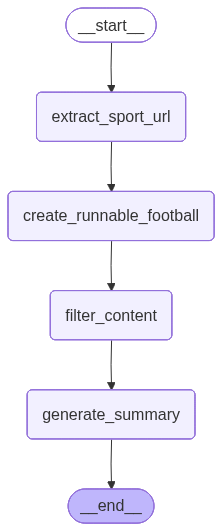

In [73]:
workflow

In [75]:
final_res=workflow.invoke({"category": "Sports", "sport": "Football", "summary": {}})

In [76]:
final_res["summary"]

{'Chelsea given fine, suspended transfer ban by PL': {'source': 'espn',
  'summary': 'Chelsea has been fined £10.75 million and given a suspended one-year transfer ban for historical breaches of Premier League rules, including undisclosed payments. The club avoided a points deduction but faces additional charges from the Football Association. Chelsea cooperated fully, disclosing documents and self-reporting breaches.'},
 'How Chelsea signed a star team with hidden payments': {'source': 'bbci',
  'summary': 'Chelsea was fined £10.75m and given a suspended transfer ban for making secret payments to agents and third-parties between 2011 and 2018, involving transfers of players like Eden Hazard and Willian. The club avoided harsher penalties due to full cooperation, though it still faces further charges from the Football Association.'},
 "Livingstone slams England cricket regime - 'No-one cares about you'": {'source': 'skysports',
  'summary': "Liam Livingstone criticized England's cricket